# Decision Tree

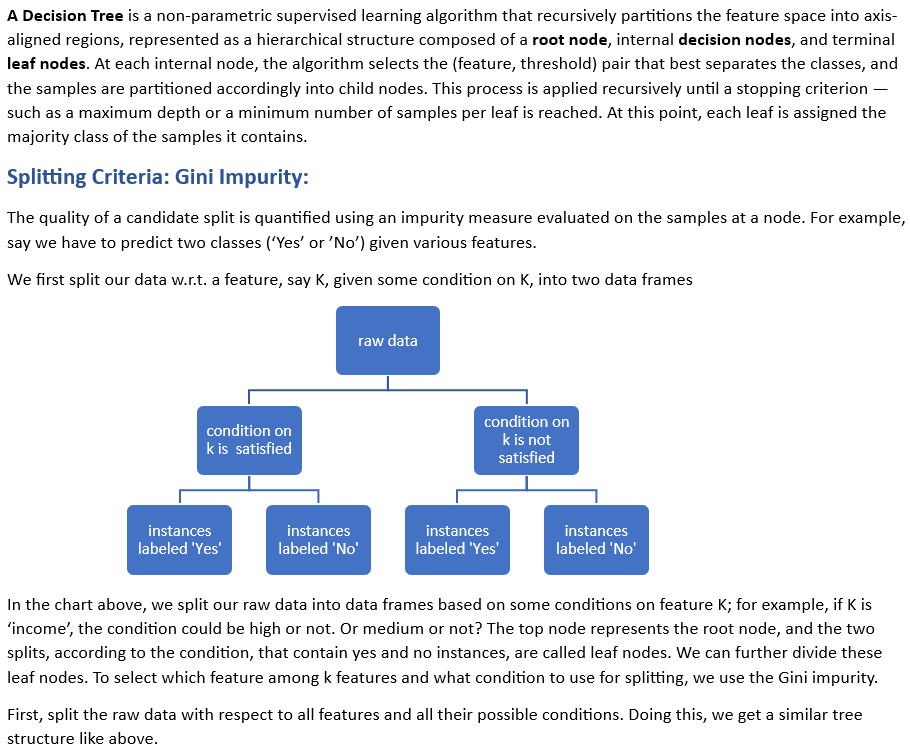
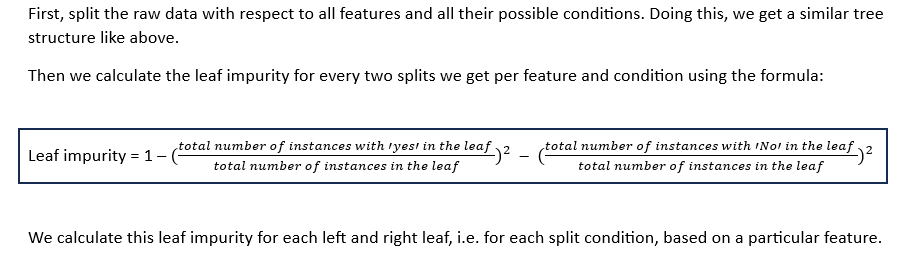
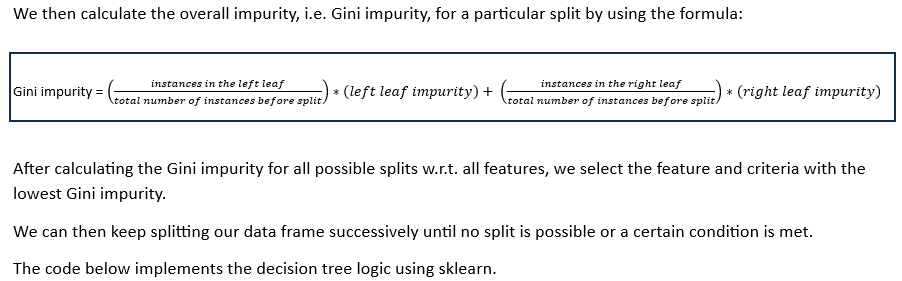

    Age  Income Is_Student Credit_Rating Buys_Phone
0    22    High         No          Fair         No
1    25    High         No     Excellent         No
2    33    High         No          Fair        Yes
3    42  Medium         No          Fair        Yes
4    45     Low        Yes          Fair        Yes
5    41     Low        Yes     Excellent         No
6    31     Low        Yes     Excellent        Yes
7    21  Medium         No          Fair         No
8    19     Low        Yes          Fair        Yes
9    44  Medium        Yes          Fair        Yes
10   20  Medium        Yes     Excellent        Yes
11   36  Medium         No     Excellent        Yes
12   38    High        Yes          Fair        Yes
13   43  Medium         No     Excellent         No


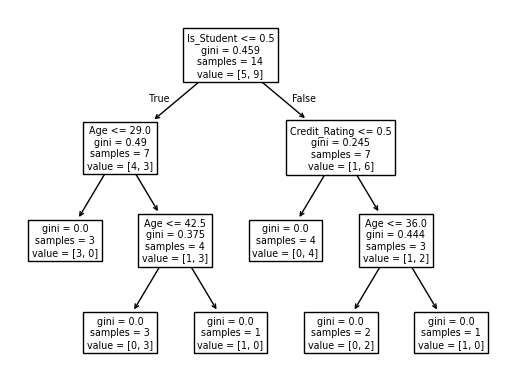

Test_case       : Age: 40  Inncome: 1 (Medium)  Is_Student: 1 (Yes)  Creadit_Rating: 1 (Excellent)
Model_perdiction: [0] 1 is Yes; 0 is No


In [4]:
import pandas as pd
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt

data = {
    'Age': [22, 25, 33, 42, 45, 41, 31, 21, 19, 44, 20, 36, 38, 43],
    'Income': ['High', 'High', 'High', 'Medium', 'Low', 'Low', 'Low', 'Medium', 'Low', 'Medium', 'Medium', 'Medium', 'High', 'Medium'],
    'Is_Student': ['No', 'No', 'No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'No'],
    'Credit_Rating': ['Fair', 'Excellent', 'Fair', 'Fair', 'Fair', 'Excellent', 'Excellent', 'Fair', 'Fair', 'Fair', 'Excellent', 'Excellent', 'Fair', 'Excellent'],
    'Buys_Phone': ['No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'No', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'No']
}

df = pd.DataFrame(data)
print(df)
income_num = {'High': 2, 'Medium': 1, 'Low': 0}
Is_Student_num = {'Yes': 1, 'No': 0}
Credit_Rating_num = {'Excellent': 1, 'Fair': 0}
Buys_Phone_num = {'Yes': 1, 'No': 0}

df['Income'] = df['Income'].map(income_num)
df['Is_Student'] = df['Is_Student'].map(Is_Student_num)
df['Credit_Rating'] = df['Credit_Rating'].map(Credit_Rating_num)
df['Buys_Phone'] = df['Buys_Phone'].map(Buys_Phone_num)

features = ['Age', 'Income', 'Is_Student', 'Credit_Rating']

X = df[features]
y = df['Buys_Phone']

dtree = DecisionTreeClassifier()
dtree = dtree.fit(X, y)

tree.plot_tree(dtree, feature_names=features)
plt.show()

test_data = pd.DataFrame([[40, 1, 1, 1]], columns=features)
print('Test_case       :','Age:',40,' Inncome:',1,'(Medium)',' Is_Student:',1,'(Yes)',' Creadit_Rating:',1,'(Excellent)')
print('Model_perdiction:',dtree.predict(test_data),'1 is Yes; 0 is No')

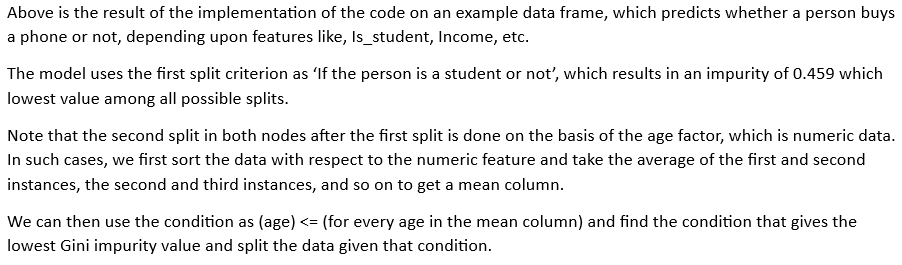

## From scratch implementation of Gini impurity logic

In [5]:
import pandas as pd

data = {
    'Age': [22, 25, 33, 42, 45, 41, 31, 21, 19, 44, 20, 36, 38, 43],
    'Income': ['High', 'High', 'High', 'Medium', 'Low', 'Low', 'Low', 'Medium', 'Low', 'Medium', 'Medium', 'Medium', 'High', 'Medium'],
    'Is_Student': ['No', 'No', 'No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'No'],
    'Credit_Rating': ['Fair', 'Excellent', 'Fair', 'Fair', 'Fair', 'Excellent', 'Excellent', 'Fair', 'Fair', 'Fair', 'Excellent', 'Excellent', 'Fair', 'Excellent'],
    'Buys_Phone': ['No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'No', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'No']
}

df = pd.DataFrame(data)

class node:
    def __init__(self,data):
        self.data = data
        self.left = None
        self.right = None

df2 = df.copy()


def geni_impurity(data,feature,target):
    if data[feature].dtype != int:
        sets = data[feature].unique()
        set_dict = {}
        for ele in sets:
            set_dict[ele] = [[0,0],[0,0]]
            for i in range(len(data[feature])):
                if data[feature][i] == ele:
                    if data[target][i] == 'Yes': set_dict[ele][0][0] += 1
                    else: set_dict[ele][0][1] += 1
                else:
                    if data[target][i] == 'Yes': set_dict[ele][1][0] += 1
                    else: set_dict[ele][1][1] += 1
        print(set_dict)
        
        impurity = {}
        for ele in sets:
            left_yes = set_dict[ele][0][0]
            left_no = set_dict[ele][0][1]
            right_yes = set_dict[ele][1][0]
            right_no = set_dict[ele][1][1]
            
            total_left = left_yes + left_no
            total_right = right_yes + right_no
    
            if total_left == 0 or total_right == 0:
                continue
        
            leaf_left = 1 - (left_yes / total_left)**2 - (left_no / total_left)**2
            leaf_right = 1 - (right_yes / total_right)**2 - (right_no / total_right)**2
    
            total_samples = total_left + total_right
            total_impurity = (total_left / total_samples) * leaf_left + (total_right / total_samples) * leaf_right
            impurity[ele] = total_impurity
        
        print(impurity)    
        
        curr_min_key = sets[0]
        curr_min_item = impurity[sets[0]]
        for key, value in impurity.items():
            if value <= curr_min_item:
                curr_min_key = key
                curr_min_item = value
        return curr_min_key, curr_min_item
    else:
        data_sorted = data.sort_values(by=feature, ascending = True).reset_index(drop=True)
        avg = []
        for i in range(len(data_sorted[feature])-1):
            avg.append(float(data_sorted[feature].iloc[i]+data_sorted[feature].iloc[i+1])/2)
        leaf_impurity = {}
        for ele in avg:
            leaf_impurity[f'< {float(ele)}'] = [[0,0],[0,0]]
            for i in range(len(data_sorted[feature])):
                if data_sorted[feature].iloc[i] < float(ele):
                    if data_sorted[target].iloc[i] == 'Yes': leaf_impurity[f'< {ele}'][0][0] += 1
                    else: leaf_impurity[f'< {ele}'][0][1] += 1
                else:
                    if data_sorted[target].iloc[i] == 'Yes': leaf_impurity[f'< {ele}'][1][0] += 1
                    else: leaf_impurity[f'< {ele}'][1][1] += 1
        print(leaf_impurity)
        
        impurity = {}
        for ele in avg:
            left_yes = leaf_impurity[f'< {ele}'][0][0]
            left_no = leaf_impurity[f'< {ele}'][0][1]
            right_yes = leaf_impurity[f'< {ele}'][1][0]
            right_no = leaf_impurity[f'< {ele}'][1][1]
    
            total_left = left_yes + left_no
            total_right = right_yes + right_no
    
            if total_left == 0 or total_right == 0:
                continue
        
            leaf_left = 1 - (left_yes / total_left)**2 - (left_no / total_left)**2
            leaf_right = 1 - (right_yes / total_right)**2 - (right_no / total_right)**2
    
            total_samples = total_left + total_right
            total_impurity = (total_left / total_samples) * leaf_left + (total_right / total_samples) * leaf_right
            impurity[f'< {ele}'] = total_impurity

        print(impurity)
        
        curr_min_key = f'< {avg[0]}'
        curr_min_item = impurity.get(curr_min_key, float('inf'))
        for key, value in impurity.items():
            if value <= curr_min_item:
                curr_min_key = key
                curr_min_item = value
        
        return curr_min_key, curr_min_item

def tree(data_frame,target):
    root = node(data_frame)
    decission = {}
    for col in data_frame.columns:
        if col != 'Buys_Phone':
            key, val = geni_impurity(df,col,'Buys_Phone')
            decission[col] = [key, val]
    print(decission)
    col = None
    operation = None
    min_geni = 2
    for key, value in decission.items():
          if value[1] < min_geni:
              min_geni = value[1]
              col = key
              operation = value[0]
    print('best split :',col,' ',operation,' ',min_geni)
    df3 = df2.loc[df2[col] == operation]
    print(df3)
    df4 = df2.loc[df2[col] != operation]
    print(df4) 

tree(df2,'Buys_Phone')

{'< 19.5': [[1, 0], [8, 5]], '< 20.5': [[2, 0], [7, 5]], '< 21.5': [[2, 1], [7, 4]], '< 23.5': [[2, 2], [7, 3]], '< 28.0': [[2, 3], [7, 2]], '< 32.0': [[3, 3], [6, 2]], '< 34.5': [[4, 3], [5, 2]], '< 37.0': [[5, 3], [4, 2]], '< 39.5': [[6, 3], [3, 2]], '< 41.5': [[6, 4], [3, 1]], '< 42.5': [[7, 4], [2, 1]], '< 43.5': [[7, 5], [2, 0]], '< 44.5': [[8, 5], [1, 0]]}
{'< 19.5': 0.43956043956043955, '< 20.5': 0.4166666666666665, '< 21.5': 0.4588744588744589, '< 23.5': 0.4428571428571429, '< 28.0': 0.3936507936507937, '< 32.0': 0.42857142857142855, '< 34.5': 0.44897959183673475, '< 37.0': 0.4583333333333333, '< 39.5': 0.4571428571428572, '< 41.5': 0.45, '< 42.5': 0.4588744588744589, '< 43.5': 0.4166666666666665, '< 44.5': 0.43956043956043955}
{'High': [[2, 2], [7, 3]], 'Medium': [[4, 2], [5, 3]], 'Low': [[3, 1], [6, 4]]}
{'High': 0.4428571428571429, 'Medium': 0.4583333333333333, 'Low': 0.45}
{'No': [[3, 4], [6, 1]], 'Yes': [[6, 1], [3, 4]]}
{'No': 0.3673469387755103, 'Yes': 0.3673469387755103